In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("50_Startups.CSV")

In [3]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)

In [5]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='str')

In [7]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]

In [8]:
dependent=dataset[['Profit']]

In [10]:
from sklearn.model_selection import train_test_split
X_Train,X_Test,Y_Train,Y_Test=train_test_split(independent,dependent,test_size=0.30,random_state=0)


In [11]:
X_Train,X_Test,Y_Train,Y_Test

(    R&D Spend  Administration  Marketing Spend  State_Florida  State_New York
 7   130298.13       145530.06        323876.68              1               0
 14  119943.24       156547.42        256512.92              1               0
 45    1000.23       124153.04          1903.93              0               1
 48     542.05        51743.15             0.00              0               1
 29   65605.48       153032.06        107138.38              0               1
 15  114523.61       122616.84        261776.23              0               1
 30   61994.48       115641.28         91131.24              1               0
 32   63408.86       129219.61         46085.25              0               0
 16   78013.11       121597.55        264346.06              0               0
 42   23640.93        96189.63        148001.11              0               0
 20   76253.86       113867.30        298664.47              0               0
 43   15505.73       127382.30         35534.17     

In [12]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor=regressor.fit(X_Train,Y_Train)

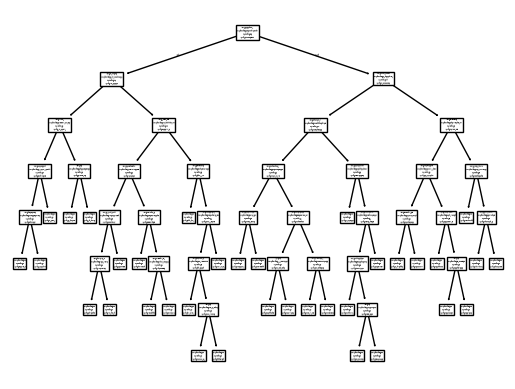

In [13]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [15]:
y_pred =regressor.predict(X_Test)

In [16]:
#model evaluation
from sklearn.metrics import r2_score
r_score=r2_score(Y_Test,y_pred)

In [17]:
r_score

0.9060304019988985

In [18]:
import pickle
filename="saved_filename_profit.sav"
pickle.dump(regressor,open(filename,"wb"))

In [19]:
#load model

loaded_model =pickle.load(open(filename,"rb"))

In [24]:
#predicting with values

rd=int(input("RD:"))
sex=int(input("sex:"))
bmi=int(input("bmi:"))
children=int(input("children:"))
smoker=int(input("smoker:"))
      
result=loaded_model.predict([[rd,sex,bmi,children,smoker]])
print("Profit:",result)

RD: 345
sex: 1
bmi: 45
children: 2
smoker: 0


Profit: [35673.41]


C:\Users\rajam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
